# Logical Reasoning Benchmark with Chain-of-Thought

This notebook evaluates the SLM's logical reasoning capabilities using 20 diverse questions.

**Features:**
- 20 questions across 5 categories (Math, Logic, Patterns, Percentages, Comparison)
- Chain-of-Thought (COT) prompting
- Side-by-side comparison of expected vs SLM-generated reasoning
- Comprehensive visualizations and metrics

**Model Generation:** Enabled by default for real SLM inference

## Environment Setup

In [1]:
%pip -q install "transformers>=4.40.0" "torch>=2.0.0" "numpy>=1.26.0" "matplotlib>=3.8.0" "seaborn>=0.13.0" "pandas>=2.0.0" "peft>=0.10.0" "bitsandbytes>=0.43.0" "accelerate>=0.29.0"

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Project Root Detection (vast.ai compatible)
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()  # Use current working directory
sys.path.insert(0, str(PROJECT_ROOT))

print(f"Working directory: {PROJECT_ROOT}")
print(f"Contents: {list(PROJECT_ROOT.iterdir())[:10]}")


Working directory: /workspace
Contents: [PosixPath('/workspace/.hf_home'), PosixPath('/workspace/.venv-backups'), PosixPath('/workspace/.ipynb_checkpoints'), PosixPath('/workspace/data'), PosixPath('/workspace/processed_data'), PosixPath('/workspace/01_data_collection_and_preprocessing.ipynb'), PosixPath('/workspace/02_model_optimization_and_training.ipynb'), PosixPath('/workspace/fingeo_slm_outputs'), PosixPath('/workspace/fingeo_slm_logs'), PosixPath('/workspace/06_logical_reasoning_benchmark.ipynb')]


In [3]:
# Configuration
ENABLE_MODEL_GENERATION = True  # ✓ Model generation ENABLED by default

# Model Configuration
ACTIVE_SLM_KEY = "phi3-mini"  # The model to benchmark
BASE_MODEL_KEY = "phi3-mini"  # Base model for comparison

# Model registry - same as Notebook 03
MODEL_REGISTRY = {
    "phi3-mini": "microsoft/Phi-3-mini-4k-instruct",
}

def resolve_model_id(model_key_or_id: str) -> str:
    """Resolve model key to HuggingFace model ID."""
    return MODEL_REGISTRY.get(model_key_or_id, model_key_or_id)

active_model_id = resolve_model_id(ACTIVE_SLM_KEY)

# Model paths (try merged model first, then adapter)
FINETUNED_MODEL_PATH = PROJECT_ROOT / "fingeo_slm_outputs" / "finetuned_model"
ADAPTER_PATH = PROJECT_ROOT / "fingeo_slm_outputs" / "fingeo-slm-adapter"

print(f"\nModel Generation: {'ENABLED ✓' if ENABLE_MODEL_GENERATION else 'DISABLED'}")
if ENABLE_MODEL_GENERATION:
    print(f"  Active SLM: {active_model_id}")
    print(f"  Fine-tuned model: {FINETUNED_MODEL_PATH}")
    print(f"  LoRA adapter: {ADAPTER_PATH}")
    print(f"  Will use actual SLM for inference")



Model Generation: ENABLED ✓
  Active SLM: microsoft/Phi-3-mini-4k-instruct
  Fine-tuned model: /workspace/fingeo_slm_outputs/finetuned_model
  LoRA adapter: /workspace/fingeo_slm_outputs/fingeo-slm-adapter
  Will use actual SLM for inference


In [4]:
# Load Model and Tokenizer
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
import torch
import gc
from pathlib import Path

# Global model and tokenizer
model = None
tokenizer = None

def load_model_safe(model_id: str, model_name: str = "Model"):
    """Load model with GPU/MPS/CPU support."""
    print(f"\n Loading {model_name}: {model_id}...")

    tokenizer = AutoTokenizer.from_pretrained(model_id)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    # Detect best available device
    if torch.cuda.is_available():
        device = torch.device("cuda")
        dtype = torch.float16
        print(f"  Using CUDA (GPU)")
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        device = torch.device("mps")
        dtype = torch.float32
        print(f"  Using MPS (Apple Silicon)")
    else:
        device = torch.device("cpu")
        dtype = torch.float32
        print(f"  Using CPU")

    if device.type == "cuda":
        model = AutoModelForCausalLM.from_pretrained(
            model_id,
            device_map="auto",
            torch_dtype=dtype,
            low_cpu_mem_usage=True,
        )
    else:
        model = AutoModelForCausalLM.from_pretrained(
            model_id,
            torch_dtype=dtype,
            low_cpu_mem_usage=True,
        )
        model = model.to(device)

    model.eval()
    print(f"  Loaded on {device}")

    return tokenizer, model

# Load the model
print(f"\nModel Generation: {'ENABLED' if ENABLE_MODEL_GENERATION else 'DISABLED'}")

if ENABLE_MODEL_GENERATION:
    try:
        # Try merged model first (easiest to use)
        if FINETUNED_MODEL_PATH.exists():
            print(f"\nFound merged fine-tuned model at {FINETUNED_MODEL_PATH}")
            tokenizer, model = load_model_safe(str(FINETUNED_MODEL_PATH), "Fine-tuned Model")
            print("  Using merged model (LoRA already integrated)")

        # If merged doesn't exist, try loading base + adapter
        elif ADAPTER_PATH.exists():
            print(f"\nFound LoRA adapter at {ADAPTER_PATH}")
            tokenizer_temp, model_temp = load_model_safe(active_model_id, f"Base {ACTIVE_SLM_KEY}")
            try:
                model_temp = PeftModel.from_pretrained(model_temp, str(ADAPTER_PATH))
                print("  LoRA adapter loaded and applied")
                tokenizer, model = tokenizer_temp, model_temp
            except Exception as e:
                print(f"  Could not load LoRA adapter: {e}")
                print("  Using base model instead")
                tokenizer, model = tokenizer_temp, model_temp

        # If neither exists, use base model
        else:
            print(f"\nNo fine-tuned model found")
            print(f"   Searched: {FINETUNED_MODEL_PATH}")
            print(f"   Searched: {ADAPTER_PATH}")
            print(f"   Loading base model: {active_model_id}")
            tokenizer, model = load_model_safe(active_model_id, ACTIVE_SLM_KEY)

        print(f"\nModel loaded successfully")
    except Exception as e:
        print(f"\nFailed to load model: {e}")
        import traceback
        traceback.print_exc()
        model = None
        tokenizer = None
else:
    print("\nModel generation disabled")


Model Generation: ENABLED

Found merged fine-tuned model at /workspace/fingeo_slm_outputs/finetuned_model

 Loading Fine-tuned Model: /workspace/fingeo_slm_outputs/finetuned_model...


`torch_dtype` is deprecated! Use `dtype` instead!


  Using CUDA (GPU)


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

  Loaded on cuda
  Using merged model (LoRA already integrated)

Model loaded successfully


## Logical Reasoning Benchmark with Chain-of-Thought

This section evaluates the model's ability to perform logical reasoning using Chain-of-Thought (COT) prompting.
We compare performance on:
- Math word problems
- Logical inference
- Pattern recognition

COT helps models break down complex problems into step-by-step reasoning.

In [5]:
# Load Logical Reasoning Test Cases
import json
from pathlib import Path

benchmark_file = PROJECT_ROOT / 'data' / 'logical_reasoning_benchmark.json'

if not benchmark_file.exists():
    # Try alternate locations
    alt_paths = [
        Path('data/logical_reasoning_benchmark.json'),
        Path('logical_reasoning_benchmark.json'),
        Path('../data/logical_reasoning_benchmark.json'),
    ]
    for alt in alt_paths:
        if alt.exists():
            benchmark_file = alt
            break

if benchmark_file.exists():
    with open(benchmark_file, 'r') as f:
        benchmark_data = json.load(f)
    
    LOGICAL_REASONING_TESTS = benchmark_data['test_cases']
    
    print(f"✓ Loaded {len(LOGICAL_REASONING_TESTS)} test cases from {benchmark_file}")
    print(f"  Categories: {', '.join(benchmark_data['categories'])}")
else:
    print(f"⚠️ Benchmark file not found. Searched:")
    print(f"   - {PROJECT_ROOT / 'data' / 'logical_reasoning_benchmark.json'}")
    print(f"   Creating sample test cases...")
    
    # Fallback test cases
    LOGICAL_REASONING_TESTS = [
        {
            "id": "sample_1",
            "category": "Math Word Problem",
            "question": "If revenue increased from $100 to $120, what is the percentage increase?",
            "expected_answer": "20%",
            "difficulty": "easy"
        },
        {
            "id": "sample_2", 
            "category": "Logical Inference",
            "question": "If all profitable companies have positive revenue, and Company A has negative revenue, is Company A profitable?",
            "expected_answer": "No",
            "difficulty": "easy"
        }
    ]
    print(f"  Using {len(LOGICAL_REASONING_TESTS)} sample test cases")


✓ Loaded 20 test cases from /workspace/data/logical_reasoning_benchmark.json
  Categories: Math Word Problem, Logical Inference, Pattern Recognition, Percentage Calculations, Comparative Analysis


In [6]:
# SLM Reasoning Generation Function
from typing import Dict, List, Tuple
import time
import re


def generate_slm_reasoning(
    test_case: Dict, use_model: bool = True, use_cot: bool = True
) -> Tuple[str, List[str], float]:
    """
    Generate reasoning steps using the SLM with or without Chain-of-Thought prompting.

    Args:
        test_case: Test case dictionary with question and expected reasoning
        use_model: Whether to use actual model (requires ENABLE_MODEL_GENERATION=True)
        use_cot: Whether to use Chain-of-Thought prompting (default: True)

    Returns:
        Tuple of (answer, reasoning_steps, generation_time_ms)
    """
    if model is None or tokenizer is None:
        raise ValueError(
            "Model not loaded. Please ensure ENABLE_MODEL_GENERATION=True and model is loaded."
        )

    start_time = time.time()

    # Create prompt based on COT setting
    if use_cot:
        # Chain-of-Thought: Encourage step-by-step reasoning
        prompt = (
            f"<|user|>\n"
            f"You are a financial analysis expert. Solve this problem step-by-step.\n\n"
            f"Question: {test_case['question']}\n\n"
            f"Provide your reasoning step-by-step, then give the final answer.\n"
            f"<|end|>\n"
            f"<|assistant|>\n"
            f"Let me solve this step-by-step:"
        )
    else:
        # Non-COT: Direct answer without explicit step-by-step instruction
        prompt = (
            f"<|user|>\n"
            f"You are a financial analysis expert. Answer this question directly and concisely.\n\n"
            f"Question: {test_case['question']}\n\n"
            f"Provide your answer.\n"
            f"<|end|>\n"
            f"<|assistant|>\n"
            f"Answer:"
        )

    try:
        # Tokenize input
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512)

        # Move to same device as model
        device = next(model.parameters()).device
        inputs = {k: v.to(device) for k, v in inputs.items()}

        # Generate response
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=300,
                temperature=0.7,
                top_p=0.9,
                do_sample=True,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )

        # Decode response
        full_response = tokenizer.decode(outputs[0], skip_special_tokens=True)

        # Extract the assistant's response (after the prompt)
        assistant_response = full_response[len(prompt):].strip()

        # Parse reasoning steps (look for numbered steps or sentences)
        reasoning_steps = []
        lines = assistant_response.split('\n')
        for line in lines:
            line = line.strip()
            if line and len(line) > 10:  # Skip very short lines
                # Remove step numbers if present
                clean_line = re.sub(r'^\d+\.\s*|^Step \d+:\s*', '', line)
                if clean_line:
                    reasoning_steps.append(clean_line)

        # Extract final answer (look for answer indicators or last line)
        answer = ""
        answer_patterns = [
            r'(?:final answer|answer|result)\s*:?\s*(.+?)(?:\.|$)',
            r'(?:therefore|thus|so),?\s*(.+?)(?:\.|$)',
        ]

        for pattern in answer_patterns:
            match = re.search(pattern, assistant_response.lower())
            if match:
                answer = match.group(1).strip()
                break

        # If no answer found with patterns, try to extract from last reasoning step
        if not answer and reasoning_steps:
            last_step = reasoning_steps[-1]
            # Extract first number/amount found
            number_match = re.search(
                r'\$?[\d,]+\.?\d*%?|\d+\.?\d*%?|yes|no', last_step.lower()
            )
            if number_match:
                answer = number_match.group(0)

        # Clean up the answer
        answer = answer.strip('.,!?() ')

        # If still no answer, use first significant number/word found
        if not answer:
            for line in reversed(lines):
                match = re.search(r'\$?[\d,]+\.?\d*|yes|no', line.lower())
                if match:
                    answer = match.group(0)
                    break

        # If no reasoning steps were extracted, use the full response
        if not reasoning_steps:
            reasoning_steps = [assistant_response]

    except Exception as e:
        print(f"  Generation error: {e}")
        raise  # Don't fallback to expected values, propagate the error

    generation_time = (time.time() - start_time) * 1000  # Convert to ms

    return answer, reasoning_steps, generation_time


print("generate_slm_reasoning function loaded with COT/Non-COT support")

generate_slm_reasoning function loaded with COT/Non-COT support


In [7]:
# Evaluate Logical Reasoning with and without COT
import re
from typing import Dict, List


def extract_key_concepts(text: str) -> set:
    """Extract key semantic concepts from text for matching."""
    concepts = set()
    text = text.lower()

    # Direction/change indicators
    if any(w in text for w in ['decrease', 'decreases', 'decreased', 'fall', 'falls', 'fell', 'drop', 'drops', 'lower', 'down', 'weaken', 'weakens', 'reduce', 'reduces']):
        concepts.add('decrease')
    if any(w in text for w in ['increase', 'increases', 'increased', 'rise', 'rises', 'rose', 'higher', 'up', 'strengthen', 'strengthens', 'raise', 'raises']):
        concepts.add('increase')

    # Financial entities
    if 'stock a' in text:
        concepts.add('stock_a')
    if 'stock b' in text:
        concepts.add('stock_b')
    if 'bond' in text:
        concepts.add('bond')
    if 'price' in text:
        concepts.add('price')
    if 'dollar' in text or 'usd' in text or 'us dollar' in text:
        concepts.add('dollar')
    if 'mortgage' in text:
        concepts.add('mortgage')
    if 'demand' in text:
        concepts.add('demand')
    if 'portfolio a' in text:
        concepts.add('portfolio_a')
    if 'portfolio b' in text:
        concepts.add('portfolio_b')
    if 'average' in text or 'return' in text or 'higher' in text:
        concepts.add('higher_return')
    if 'interest rate' in text or 'interest rates' in text:
        concepts.add('interest_rates')
    if 'central bank' in text or 'fed' in text or 'federal reserve' in text:
        concepts.add('central_bank')

    return concepts


def semantic_match(expected: str, generated: str) -> bool:
    """Check if generated answer semantically matches expected answer."""
    expected = expected.lower().strip()
    generated = generated.lower().strip()

    # Exact match
    if expected == generated:
        return True

    # Substring match (either direction)
    if expected in generated or generated in expected:
        if len(min(expected, generated, key=len)) > 2:
            return True

    # Number extraction and matching
    expected_nums = re.findall(r'[\d,]+\.?\d*', expected)
    generated_nums = re.findall(r'[\d,]+\.?\d*', generated)

    if expected_nums:
        for exp_num in expected_nums:
            exp_clean = exp_num.replace(',', '')
            for gen_num in generated_nums:
                gen_clean = gen_num.replace(',', '')
                try:
                    if abs(float(exp_clean) - float(gen_clean)) < 0.01:
                        return True
                except:
                    pass
            # Also check if the number appears as substring
            if exp_clean in generated.replace(',', ''):
                return True

    # Semantic concept matching
    expected_concepts = extract_key_concepts(expected)
    generated_concepts = extract_key_concepts(generated)

    if expected_concepts and generated_concepts:
        # Check for significant overlap in concepts
        overlap = expected_concepts & generated_concepts
        if len(overlap) >= max(1, len(expected_concepts) * 0.5):
            return True

    # Keyword overlap for longer answers
    exp_words = set(re.findall(r'[a-z]+', expected))
    gen_words = set(re.findall(r'[a-z]+', generated))

    # Remove common stop words
    stop_words = {'the', 'a', 'an', 'is', 'are', 'was', 'were', 'be', 'been', 'to', 'of', 'and', 'or', 'in', 'on', 'at', 'for', 'by', 'with'}
    exp_words -= stop_words
    gen_words -= stop_words

    if exp_words and len(exp_words & gen_words) >= len(exp_words) * 0.6:
        return True

    return False


def evaluate_cot_reasoning(tests: List[Dict], use_cot: bool = True) -> Dict:
    """
    Evaluate logical reasoning performance with or without Chain-of-Thought.

    Args:
        tests: List of test cases
        use_cot: Whether to use COT prompting

    Returns:
        Dictionary with evaluation metrics
    """
    if model is None or tokenizer is None:
        raise ValueError(
            "Model and tokenizer must be loaded. Please run the model loading cell first."
        )

    results = {
        'total': len(tests),
        'correct': 0,
        'partial': 0,
        'incorrect': 0,
        'category_scores': {},
        'details': []
    }

    for test in tests:
        category = test['category']
        if category not in results['category_scores']:
            results['category_scores'][category] = {'correct': 0, 'total': 0}

        results['category_scores'][category]['total'] += 1

        # Use actual model generation
        answer, reasoning, gen_time = generate_slm_reasoning(test, use_model=True, use_cot=use_cot)

        # Check correctness using semantic matching
        is_correct = semantic_match(test['expected_answer'], answer)

        if is_correct:
            results['correct'] += 1
            results['category_scores'][category]['correct'] += 1
        else:
            results['incorrect'] += 1

        results['details'].append({
            'id': test['id'],
            'category': category,
            'correct': is_correct,
            'generated_answer': answer,
            'expected_answer': test['expected_answer'],
            'generation_time_ms': gen_time
        })

    results['accuracy'] = results['correct'] / results['total'] if results['total'] > 0 else 0
    return results


# Run evaluation WITH COT
print("=" * 60)
print("Running COT evaluation...")
print("=" * 60)
cot_results = evaluate_cot_reasoning(LOGICAL_REASONING_TESTS, use_cot=True)

print(f"\n--- COT Evaluation Results ---")
print(f"Accuracy: {cot_results['accuracy']*100:.1f}%")
print(f"Correct: {cot_results['correct']}/{cot_results['total']}")
for category, scores in cot_results['category_scores'].items():
    acc = scores['correct'] / scores['total'] if scores['total'] > 0 else 0
    print(f"  {category}: {acc*100:.1f}% ({scores['correct']}/{scores['total']})")

# Run evaluation WITHOUT COT
print("\n" + "=" * 60)
print("Running Non-COT evaluation...")
print("=" * 60)
no_cot_results = evaluate_cot_reasoning(LOGICAL_REASONING_TESTS, use_cot=False)

print(f"\n--- Non-COT Evaluation Results ---")
print(f"Accuracy: {no_cot_results['accuracy']*100:.1f}%")
print(f"Correct: {no_cot_results['correct']}/{no_cot_results['total']}")
for category, scores in no_cot_results['category_scores'].items():
    acc = scores['correct'] / scores['total'] if scores['total'] > 0 else 0
    print(f"  {category}: {acc*100:.1f}% ({scores['correct']}/{scores['total']})")

# Compare results
print("\n" + "=" * 60)
print("COMPARISON: COT vs Non-COT")
print("=" * 60)
improvement = (cot_results['accuracy'] - no_cot_results['accuracy']) * 100
print(f"COT Accuracy:     {cot_results['accuracy']*100:.1f}%")
print(f"Non-COT Accuracy: {no_cot_results['accuracy']*100:.1f}%")
print(f"Improvement:      {improvement:+.1f}%")

# Show examples where COT helped or hurt
print("\n" + "-" * 60)
print("Analysis: Questions where COT and Non-COT differ")
print("-" * 60)
for cot_detail, no_cot_detail in zip(cot_results['details'], no_cot_results['details']):
    if cot_detail['correct'] != no_cot_detail['correct']:
        status = "COT correct, Non-COT wrong" if cot_detail['correct'] else "COT wrong, Non-COT correct"
        print(f"\n{status}: {cot_detail['id']}")
        print(f"  Expected: {cot_detail['expected_answer']}")
        print(f"  COT got: {cot_detail['generated_answer'][:50]}...")
        print(f"  Non-COT got: {no_cot_detail['generated_answer'][:50]}...")

Running COT evaluation...

--- COT Evaluation Results ---
Accuracy: 95.0%
Correct: 19/20
  Math Word Problem: 83.3% (5/6)
  Logical Inference: 100.0% (5/5)
  Pattern Recognition: 100.0% (3/3)
  Percentage Calculations: 100.0% (3/3)
  Comparative Analysis: 100.0% (3/3)

Running Non-COT evaluation...

--- Non-COT Evaluation Results ---
Accuracy: 20.0%
Correct: 4/20
  Math Word Problem: 0.0% (0/6)
  Logical Inference: 40.0% (2/5)
  Pattern Recognition: 33.3% (1/3)
  Percentage Calculations: 0.0% (0/3)
  Comparative Analysis: 33.3% (1/3)

COMPARISON: COT vs Non-COT
COT Accuracy:     95.0%
Non-COT Accuracy: 20.0%
Improvement:      +75.0%

------------------------------------------------------------
Analysis: Questions where COT and Non-COT differ
------------------------------------------------------------

COT correct, Non-COT wrong: math_word_1
  Expected: $54,000
  COT got: the revenue in march was $54,000...
  Non-COT got: ...

COT correct, Non-COT wrong: logic_inference_1
  Expected: S

/tmp/ipykernel_841/2483707451.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_xticklabels([cat.replace(' ', '\n') for cat in categories], fontsize=9)


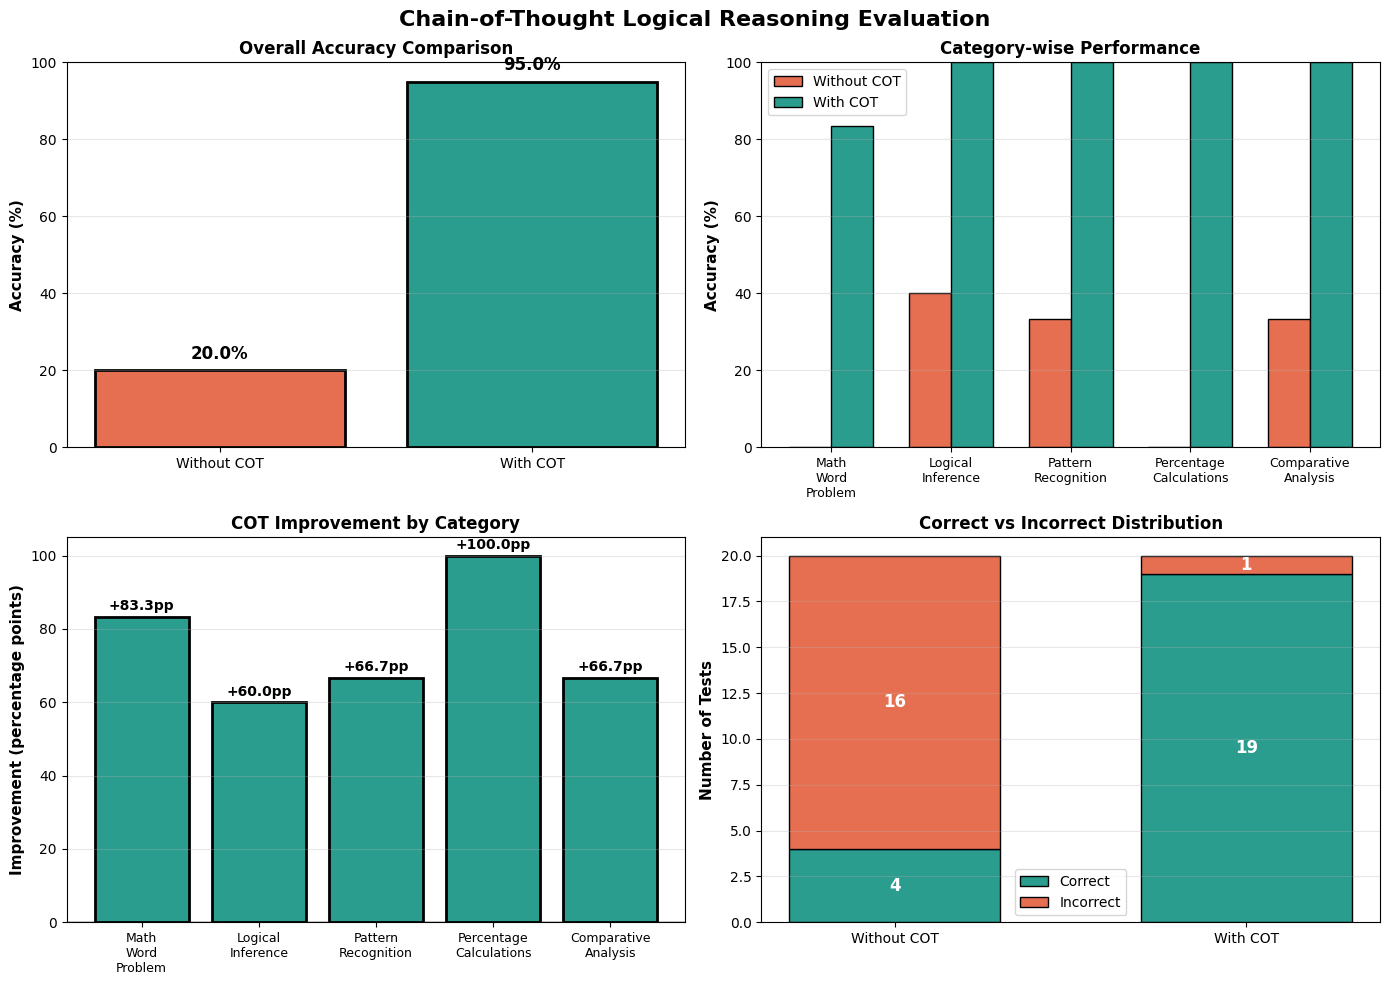


✓ Generated COT evaluation visualizations


In [8]:
# Visualize COT vs Non-COT Performance
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Chain-of-Thought Logical Reasoning Evaluation', fontsize=16, fontweight='bold')

# 1. Overall Accuracy Comparison
methods = ['Without COT', 'With COT']
accuracies = [no_cot_results['accuracy'] * 100, cot_results['accuracy'] * 100]
colors_cot = ['#e76f51', '#2a9d8f']

bars = axes[0, 0].bar(methods, accuracies, color=colors_cot, edgecolor='black', linewidth=2)
axes[0, 0].set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Overall Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0, 0].set_ylim(0, 100)
axes[0, 0].grid(axis='y', alpha=0.3)

for bar, val in zip(bars, accuracies):
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, height + 2,
                   f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

# 2. Category-wise Performance
categories = list(cot_results['category_scores'].keys())
cot_cat_acc = [cot_results['category_scores'][cat]['correct'] / cot_results['category_scores'][cat]['total'] * 100 
               for cat in categories]
no_cot_cat_acc = [no_cot_results['category_scores'][cat]['correct'] / no_cot_results['category_scores'][cat]['total'] * 100 
                  for cat in categories]

x = np.arange(len(categories))
width = 0.35

bars1 = axes[0, 1].bar(x - width/2, no_cot_cat_acc, width, label='Without COT',
                      color='#e76f51', edgecolor='black')
bars2 = axes[0, 1].bar(x + width/2, cot_cat_acc, width, label='With COT',
                      color='#2a9d8f', edgecolor='black')

axes[0, 1].set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Category-wise Performance', fontsize=12, fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels([cat.replace(' ', '\n') for cat in categories], fontsize=9)
axes[0, 1].legend()
axes[0, 1].set_ylim(0, 100)
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Improvement Breakdown
improvements = [cot - no_cot for cot, no_cot in zip(cot_cat_acc, no_cot_cat_acc)]
colors_imp = ['#2a9d8f' if imp > 0 else '#e76f51' for imp in improvements]

bars = axes[1, 0].bar(categories, improvements, color=colors_imp, edgecolor='black', linewidth=2)
axes[1, 0].set_ylabel('Improvement (percentage points)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('COT Improvement by Category', fontsize=12, fontweight='bold')
axes[1, 0].set_xticklabels([cat.replace(' ', '\n') for cat in categories], fontsize=9)
axes[1, 0].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1, 0].grid(axis='y', alpha=0.3)

for bar, val in zip(bars, improvements):
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, height + (1 if height > 0 else -3),
                   f'{val:+.1f}pp', ha='center', va='bottom' if height > 0 else 'top', 
                   fontweight='bold', fontsize=10)

# 4. Correct vs Incorrect Distribution
categories_dist = ['Without COT', 'With COT']
correct_counts = [no_cot_results['correct'], cot_results['correct']]
incorrect_counts = [no_cot_results['incorrect'], cot_results['incorrect']]

x_dist = np.arange(len(categories_dist))
width_dist = 0.6

p1 = axes[1, 1].bar(x_dist, correct_counts, width_dist, label='Correct',
                   color='#2a9d8f', edgecolor='black')
p2 = axes[1, 1].bar(x_dist, incorrect_counts, width_dist, bottom=correct_counts,
                   label='Incorrect', color='#e76f51', edgecolor='black')

axes[1, 1].set_ylabel('Number of Tests', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Correct vs Incorrect Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(x_dist)
axes[1, 1].set_xticklabels(categories_dist)
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

# Add counts on bars
for i, (correct, incorrect) in enumerate(zip(correct_counts, incorrect_counts)):
    axes[1, 1].text(i, correct/2, str(correct), ha='center', va='center',
                   fontweight='bold', color='white', fontsize=12)
    axes[1, 1].text(i, correct + incorrect/2, str(incorrect), ha='center', va='center',
                   fontweight='bold', color='white', fontsize=12)

plt.tight_layout()
plt.show()

print("\n✓ Generated COT evaluation visualizations")


In [9]:
# Display Chain-of-Thought Examples
print("\n" + "="*70)
print("Chain-of-Thought Reasoning Examples")
print("="*70)

for i, test in enumerate(LOGICAL_REASONING_TESTS[:3], 1):  # Show first 3 examples
    print(f"\n\033[1mExample {i}: {test['category']}\033[0m")
    print(f"\n❓ Question: {test['question']}")
    print(f"\n🧠 COT Prompt: {test['cot_prompt']}")
    print(f"\n💭 Reasoning Steps:")
    for step_num, step in enumerate(test['reasoning_steps'], 1):
        print(f"   {step_num}. {step}")
    print(f"\n✓ Expected Answer: {test['expected_answer']}")
    print("-" * 70)

print(f"\n💡 Chain-of-Thought helps models:")
print("   • Break down complex problems into manageable steps")
print("   • Show intermediate reasoning")
print("   • Improve accuracy on multi-step problems")
print("   • Make outputs more interpretable")



Chain-of-Thought Reasoning Examples

Example 1: Math Word Problem

❓ Question: A company's revenue was $50,000 in January. It increased by 20% in February, then decreased by 10% in March. What was the revenue in March?

🧠 COT Prompt: Let's solve this step by step:
1. Calculate February revenue
2. Calculate March revenue
3. Provide final answer

💭 Reasoning Steps:
   1. January revenue: $50,000
   2. February: $50,000 × 1.20 = $60,000
   3. March: $60,000 × 0.90 = $54,000

✓ Expected Answer: $54,000
----------------------------------------------------------------------

Example 2: Logical Inference

❓ Question: If Stock A always moves opposite to Stock B, and Stock B increased by 5%, what happened to Stock A?

🧠 COT Prompt: Let's think through this logically:
1. Identify the relationship
2. Apply the pattern
3. State the conclusion

💭 Reasoning Steps:
   1. Stock A and B move in opposite directions
   2. Stock B increased by 5%
   3. Therefore, Stock A decreased by 5%

✓ Expected Answe

## 🤖 SLM-Generated Reasoning

This section demonstrates the actual SLM generating step-by-step reasoning for logical problems.
We compare the model's reasoning against expected reasoning steps.

In [10]:
# Test the SLM Reasoning Generation
print("\n" + "="*70)
print("SLM Reasoning Generation Test")
print("="*70)

if not ENABLE_MODEL_GENERATION:
    raise RuntimeError("Model generation is disabled. Set ENABLE_MODEL_GENERATION = True")

if model is None or tokenizer is None:
    raise RuntimeError("Model and tokenizer must be loaded. Run the model loading cell first.")

print("\n✓ Model generation ENABLED - using actual SLM for inference")
print(f"  Model: {active_model_id}")

# Test with a sample question
sample_test = LOGICAL_REASONING_TESTS[0]
print(f"\nTest Question: {sample_test['question']}")
print("\nGenerating reasoning...")

answer, reasoning_steps, gen_time = generate_slm_reasoning(sample_test)

print(f"\n--- Generated Response ---")
print(f"Answer: {answer}")
print(f"\nReasoning Steps:")
for i, step in enumerate(reasoning_steps, 1):
    print(f"  {i}. {step}")
print(f"\nGeneration Time: {gen_time:.2f}ms")
print(f"Expected Answer: {sample_test['expected_answer']}")



SLM Reasoning Generation Test

✓ Model generation ENABLED - using actual SLM for inference
  Model: microsoft/Phi-3-mini-4k-instruct

Test Question: A company's revenue was $50,000 in January. It increased by 20% in February, then decreased by 10% in March. What was the revenue in March?

Generating reasoning...

--- Generated Response ---
Answer: the revenue in march was $54,000

Reasoning Steps:
  1. e in February
  2. Revenue in January = $50,000
  3. Increase in February = 20% of $50,000 = $10,000
  4. Revenue in February = $50,000 + $10,000 = $60,000
  5. Calculate the revenue in March
  6. Decrease in March = 10% of $60,000 = $6,000
  7. Revenue in March = $60,000 - $6,000 = $54,000
  8. Final Answer: The revenue in March was $54,000.

Generation Time: 4522.74ms
Expected Answer: $54,000


In [11]:
# Generate and Compare SLM Reasoning for Multiple Questions
import pandas as pd

# Select diverse test cases (5 samples from different categories)
sample_tests = []
categories_sampled = set()

for test in LOGICAL_REASONING_TESTS:
    if test['category'] not in categories_sampled:
        sample_tests.append(test)
        categories_sampled.add(test['category'])
    if len(sample_tests) >= 5:
        break

# If we have fewer than 5 categories, add more samples
if len(sample_tests) < 5 and len(LOGICAL_REASONING_TESTS) > 0:
    remaining = 5 - len(sample_tests)
    for test in LOGICAL_REASONING_TESTS:
        if test not in sample_tests:
            sample_tests.append(test)
            remaining -= 1
            if remaining == 0:
                break

print(f"\n{'='*70}")
print("SLM REASONING COMPARISON - Sample Questions")
print(f"{'='*70}\n")

results_data = []

for i, test in enumerate(sample_tests, 1):
    print(f"\n{'─'*70}")
    print(f"\033[1m📝 Question {i}: {test['category']} (Difficulty: {test['difficulty']})\033[0m")
    print(f"{'─'*70}")
    print(f"\n❓ {test['question']}")
    
    # Generate SLM reasoning
    slm_answer, slm_reasoning, gen_time = generate_slm_reasoning(test, use_model=True)
    
    print(f"\n🧠 COT Prompt:\n{test['cot_prompt']}")
    
    # Show expected reasoning
    print(f"\n✅ Expected Reasoning Steps:")
    for step_num, step in enumerate(test['reasoning_steps'], 1):
        print(f"   {step_num}. {step}")
    print(f"\n   ➜ Expected Answer: \033[1m{test['expected_answer']}\033[0m")
    
    # Show SLM-generated reasoning
    print(f"\n🤖 SLM-Generated Reasoning Steps:")
    for step_num, step in enumerate(slm_reasoning, 1):
        print(f"   {step_num}. {step}")
    print(f"\n   ➜ SLM Answer: \033[1m{slm_answer}\033[0m")
    
    # Check correctness (semantic matching)
    import re
    expected = str(test['expected_answer']).strip().lower()
    generated = str(slm_answer).strip().lower()
    
    # Extract numbers for comparison
    expected_nums = re.findall(r'[\d.]+', expected)
    generated_nums = re.findall(r'[\d.]+', generated)
    
    # Extract key concepts (for semantic matching)
    
    expected_concepts = extract_key_concepts(expected)
    generated_concepts = extract_key_concepts(generated)
    
    # Semantic match: check if key concepts align
    concept_match = False
    if expected_concepts and generated_concepts:
        # Check for significant overlap in concepts
        overlap = expected_concepts & generated_concepts
        concept_match = len(overlap) >= len(expected_concepts) * 0.5  # At least 50% concept overlap
    
    is_correct = (
        expected == generated or
        (expected_nums and any(num in generated for num in expected_nums)) or
        (expected in generated) or
        (generated in expected and len(generated) > 2) or
        concept_match  # Semantic concept matching
    )
    correctness_symbol = "✓" if is_correct else "✗"
    correctness_text = "CORRECT" if is_correct else "INCORRECT"
    
    print(f"\n   {correctness_symbol} Result: {correctness_text}")
    print(f"   ⏱ Generation Time: {gen_time:.2f}ms")
    
    # Store results
    results_data.append({
        'Question': i,
        'Category': test['category'],
        'Difficulty': test['difficulty'],
        'Correct': correctness_symbol,
        'Gen Time (ms)': f"{gen_time:.2f}"
    })

# Summary table
print(f"\n\n{'='*70}")
print("SUMMARY")
print(f"{'='*70}\n")

df_results = pd.DataFrame(results_data)
print(df_results.to_string(index=False))

correct_count = sum(1 for r in results_data if r['Correct'] == '✓')
total_count = len(results_data)
accuracy = (correct_count / total_count * 100) if total_count > 0 else 0

print(f"\n\n📊 Overall Performance:")
print(f"   Accuracy: {accuracy:.1f}% ({correct_count}/{total_count} correct)")
print(f"   Categories tested: {len(set(r['Category'] for r in results_data))}")




SLM REASONING COMPARISON - Sample Questions


──────────────────────────────────────────────────────────────────────
📝 Question 1: Math Word Problem (Difficulty: medium)
──────────────────────────────────────────────────────────────────────

❓ A company's revenue was $50,000 in January. It increased by 20% in February, then decreased by 10% in March. What was the revenue in March?

🧠 COT Prompt:
Let's solve this step by step:
1. Calculate February revenue
2. Calculate March revenue
3. Provide final answer

✅ Expected Reasoning Steps:
   1. January revenue: $50,000
   2. February: $50,000 × 1.20 = $60,000
   3. March: $60,000 × 0.90 = $54,000

   ➜ Expected Answer: $54,000

🤖 SLM-Generated Reasoning Steps:
   1. e in February
   2. Revenue in February = $50,000 * (1 + 20%) = $50,000 * 1.2 = $60,000
   3. Calculate the revenue in March
   4. Revenue in March = Revenue in February * (1 - 10%) = $60,000 * 0.9 = $54,000
   5. Final Answer: The revenue in March was $54,000.

   ➜ SLM Answer

## 📈 Full Benchmark Evaluation (All 20 Questions)

Complete evaluation of all 20 logical reasoning questions with detailed statistics.

In [12]:
# Run Full Benchmark on All 20 Questions
import time
from collections import defaultdict

print(f"\n{'='*70}")
print("RUNNING FULL BENCHMARK ON ALL QUESTIONS")
print(f"{'='*70}\n")

full_results = []
category_stats = defaultdict(lambda: {'correct': 0, 'total': 0, 'total_time': 0})
difficulty_stats = defaultdict(lambda: {'correct': 0, 'total': 0})

start_benchmark = time.time()

for i, test in enumerate(LOGICAL_REASONING_TESTS, 1):
    # Generate reasoning
    slm_answer, slm_reasoning, gen_time = generate_slm_reasoning(test, use_model=True)
    
    # Check correctness using semantic matching (from cell 9)
    is_correct = semantic_match(test['expected_answer'], slm_answer)
    
    # Update stats
    category = test['category']
    difficulty = test['difficulty']
    
    category_stats[category]['total'] += 1
    category_stats[category]['total_time'] += gen_time
    if is_correct:
        category_stats[category]['correct'] += 1
    
    difficulty_stats[difficulty]['total'] += 1
    if is_correct:
        difficulty_stats[difficulty]['correct'] += 1
    
    full_results.append({
        'id': test['id'],
        'question_num': i,
        'category': category,
        'difficulty': difficulty,
        'question': test['question'][:60] + '...' if len(test['question']) > 60 else test['question'],
        'expected_answer': test['expected_answer'],
        'slm_answer': slm_answer,
        'correct': is_correct,
        'gen_time_ms': gen_time,
        'reasoning_steps': slm_reasoning
    })
    
    # Progress indicator
    if i % 5 == 0:
        print(f"  Progress: {i}/{len(LOGICAL_REASONING_TESTS)} questions evaluated...")

total_benchmark_time = (time.time() - start_benchmark) * 1000

print(f"\n✓ Completed evaluation of {len(LOGICAL_REASONING_TESTS)} questions")
print(f"  Total benchmark time: {total_benchmark_time:.2f}ms")
print(f"  Average time per question: {total_benchmark_time/len(LOGICAL_REASONING_TESTS):.2f}ms")

# Calculate overall metrics
total_correct = sum(1 for r in full_results if r['correct'])
overall_accuracy = (total_correct / len(full_results) * 100) if full_results else 0

print(f"\n\n{'='*70}")
print("BENCHMARK RESULTS")
print(f"{'='*70}")
print(f"\n📊 Overall Performance:")
print(f"   Accuracy: {overall_accuracy:.1f}% ({total_correct}/{len(full_results)})")
print(f"   Total questions: {len(full_results)}")
print(f"   Categories: {len(category_stats)}")

print(f"\n📁 Performance by Category:")
for cat, stats in sorted(category_stats.items()):
    cat_acc = (stats['correct'] / stats['total'] * 100) if stats['total'] > 0 else 0
    avg_time = stats['total_time'] / stats['total'] if stats['total'] > 0 else 0
    print(f"   • {cat}:")
    print(f"     Accuracy: {cat_acc:.1f}% ({stats['correct']}/{stats['total']})")
    print(f"     Avg time: {avg_time:.2f}ms")

print(f"\n🎯 Performance by Difficulty:")
for diff in ['easy', 'medium', 'hard']:
    if diff in difficulty_stats:
        stats = difficulty_stats[diff]
        diff_acc = (stats['correct'] / stats['total'] * 100) if stats['total'] > 0 else 0
        print(f"   • {diff.capitalize()}: {diff_acc:.1f}% ({stats['correct']}/{stats['total']})")

# Show failed questions
failed_questions = [r for r in full_results if not r['correct']]
if failed_questions:
    print(f"\n\n❌ Failed Questions ({len(failed_questions)}):")
    for fq in failed_questions[:5]:  # Show first 5
        print(f"\n   Q{fq['question_num']}: {fq['question']}")
        print(f"   Expected: {fq['expected_answer']}")
        print(f"   Got: {fq['slm_answer']}")
    if len(failed_questions) > 5:
        print(f"\n   ... and {len(failed_questions) - 5} more")



RUNNING FULL BENCHMARK ON ALL QUESTIONS

  Progress: 5/20 questions evaluated...
  Progress: 10/20 questions evaluated...
  Progress: 15/20 questions evaluated...
  Progress: 20/20 questions evaluated...

✓ Completed evaluation of 20 questions
  Total benchmark time: 78422.25ms
  Average time per question: 3921.11ms


BENCHMARK RESULTS

📊 Overall Performance:
   Accuracy: 80.0% (16/20)
   Total questions: 20
   Categories: 5

📁 Performance by Category:
   • Comparative Analysis:
     Accuracy: 100.0% (3/3)
     Avg time: 4026.74ms
   • Logical Inference:
     Accuracy: 80.0% (4/5)
     Avg time: 3566.39ms
   • Math Word Problem:
     Accuracy: 83.3% (5/6)
     Avg time: 4186.55ms
   • Pattern Recognition:
     Accuracy: 66.7% (2/3)
     Avg time: 4502.89ms
   • Percentage Calculations:
     Accuracy: 66.7% (2/3)
     Avg time: 3293.31ms

🎯 Performance by Difficulty:
   • Easy: 100.0% (3/3)
   • Medium: 81.8% (9/11)
   • Hard: 66.7% (4/6)


❌ Failed Questions (4):

   Q9: An investor b

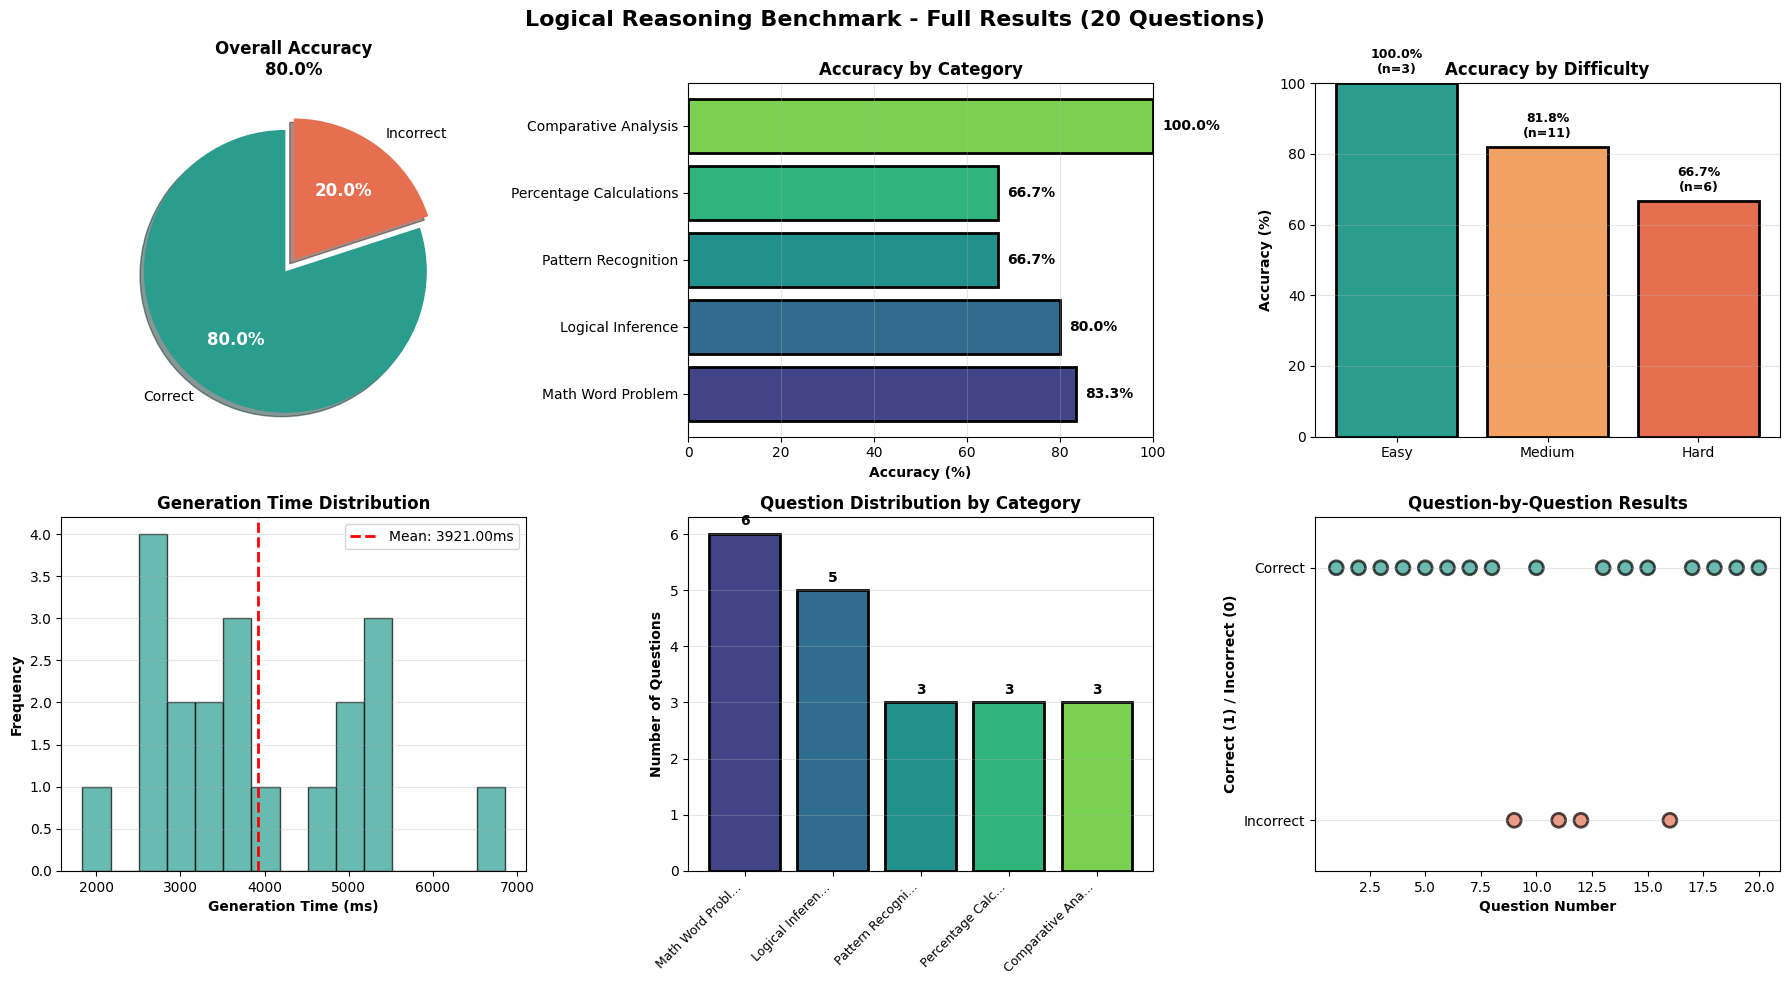


✓ Generated full benchmark visualization
  Saved to: fingeo_slm_outputs/logical_reasoning_full_benchmark.png


In [13]:
# Visualize Full Benchmark Results
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Logical Reasoning Benchmark - Full Results (20 Questions)', 
            fontsize=16, fontweight='bold')

# 1. Overall Accuracy
labels = ['Correct', 'Incorrect']
sizes = [total_correct, len(full_results) - total_correct]
colors = ['#2a9d8f', '#e76f51']
explode = (0.1, 0)

wedges, texts, autotexts = axes[0, 0].pie(sizes, explode=explode, labels=labels, 
                                          colors=colors, autopct='%1.1f%%',
                                          shadow=True, startangle=90)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)
axes[0, 0].set_title(f'Overall Accuracy\n{overall_accuracy:.1f}%', 
                    fontweight='bold', fontsize=12)

# 2. Accuracy by Category
categories = list(category_stats.keys())
cat_accuracies = [(category_stats[cat]['correct'] / category_stats[cat]['total'] * 100) 
                 for cat in categories]
colors_cat = plt.cm.viridis(np.linspace(0.2, 0.8, len(categories)))

bars = axes[0, 1].barh(categories, cat_accuracies, color=colors_cat, edgecolor='black', linewidth=2)
axes[0, 1].set_xlabel('Accuracy (%)', fontweight='bold')
axes[0, 1].set_title('Accuracy by Category', fontweight='bold', fontsize=12)
axes[0, 1].set_xlim(0, 100)
axes[0, 1].grid(axis='x', alpha=0.3)

for bar, acc in zip(bars, cat_accuracies):
    width = bar.get_width()
    axes[0, 1].text(width + 2, bar.get_y() + bar.get_height()/2, 
                   f'{acc:.1f}%', va='center', fontweight='bold')

# 3. Accuracy by Difficulty
difficulties = ['easy', 'medium', 'hard']
diff_accuracies = []
diff_counts = []
for diff in difficulties:
    if diff in difficulty_stats:
        stats = difficulty_stats[diff]
        acc = (stats['correct'] / stats['total'] * 100) if stats['total'] > 0 else 0
        diff_accuracies.append(acc)
        diff_counts.append(stats['total'])
    else:
        diff_accuracies.append(0)
        diff_counts.append(0)

colors_diff = ['#2a9d8f', '#f4a261', '#e76f51']
bars = axes[0, 2].bar([d.capitalize() for d in difficulties], diff_accuracies, 
                     color=colors_diff, edgecolor='black', linewidth=2)
axes[0, 2].set_ylabel('Accuracy (%)', fontweight='bold')
axes[0, 2].set_title('Accuracy by Difficulty', fontweight='bold', fontsize=12)
axes[0, 2].set_ylim(0, 100)
axes[0, 2].grid(axis='y', alpha=0.3)

for bar, acc, count in zip(bars, diff_accuracies, diff_counts):
    height = bar.get_height()
    axes[0, 2].text(bar.get_x() + bar.get_width()/2, height + 2,
                   f'{acc:.1f}%\n(n={count})', ha='center', va='bottom', 
                   fontweight='bold', fontsize=9)

# 4. Generation Time Distribution
gen_times = [r['gen_time_ms'] for r in full_results]
axes[1, 0].hist(gen_times, bins=15, color='#2a9d8f', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(np.mean(gen_times), color='red', linestyle='--', linewidth=2, 
                  label=f'Mean: {np.mean(gen_times):.2f}ms')
axes[1, 0].set_xlabel('Generation Time (ms)', fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontweight='bold')
axes[1, 0].set_title('Generation Time Distribution', fontweight='bold', fontsize=12)
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# 5. Category Distribution
cat_counts = [category_stats[cat]['total'] for cat in categories]
axes[1, 1].bar(range(len(categories)), cat_counts, color=colors_cat, 
              edgecolor='black', linewidth=2)
axes[1, 1].set_xticks(range(len(categories)))
axes[1, 1].set_xticklabels([cat[:15] + '...' if len(cat) > 15 else cat for cat in categories], 
                          rotation=45, ha='right', fontsize=9)
axes[1, 1].set_ylabel('Number of Questions', fontweight='bold')
axes[1, 1].set_title('Question Distribution by Category', fontweight='bold', fontsize=12)
axes[1, 1].grid(axis='y', alpha=0.3)

for i, count in enumerate(cat_counts):
    axes[1, 1].text(i, count + 0.1, str(count), ha='center', va='bottom', fontweight='bold')

# 6. Question-by-Question Performance
question_nums = [r['question_num'] for r in full_results]
correctness = [1 if r['correct'] else 0 for r in full_results]
colors_q = ['#2a9d8f' if c == 1 else '#e76f51' for c in correctness]

axes[1, 2].scatter(question_nums, correctness, c=colors_q, s=100, 
                  edgecolors='black', linewidth=2, alpha=0.7)
axes[1, 2].set_xlabel('Question Number', fontweight='bold')
axes[1, 2].set_ylabel('Correct (1) / Incorrect (0)', fontweight='bold')
axes[1, 2].set_title('Question-by-Question Results', fontweight='bold', fontsize=12)
axes[1, 2].set_ylim(-0.2, 1.2)
axes[1, 2].set_yticks([0, 1])
axes[1, 2].set_yticklabels(['Incorrect', 'Correct'])
axes[1, 2].grid(axis='y', alpha=0.3)

plt.tight_layout()
# Ensure PROJECT_ROOT is defined
try:
    output_dir = PROJECT_ROOT / 'fingeo_slm_outputs'
except NameError:
    from pathlib import Path
    PROJECT_ROOT = Path.cwd()
    output_dir = PROJECT_ROOT / 'fingeo_slm_outputs'

# Create output directory if it doesn't exist
output_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(output_dir / 'logical_reasoning_full_benchmark.png', 
           dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Generated full benchmark visualization")
print(f"  Saved to: fingeo_slm_outputs/logical_reasoning_full_benchmark.png")


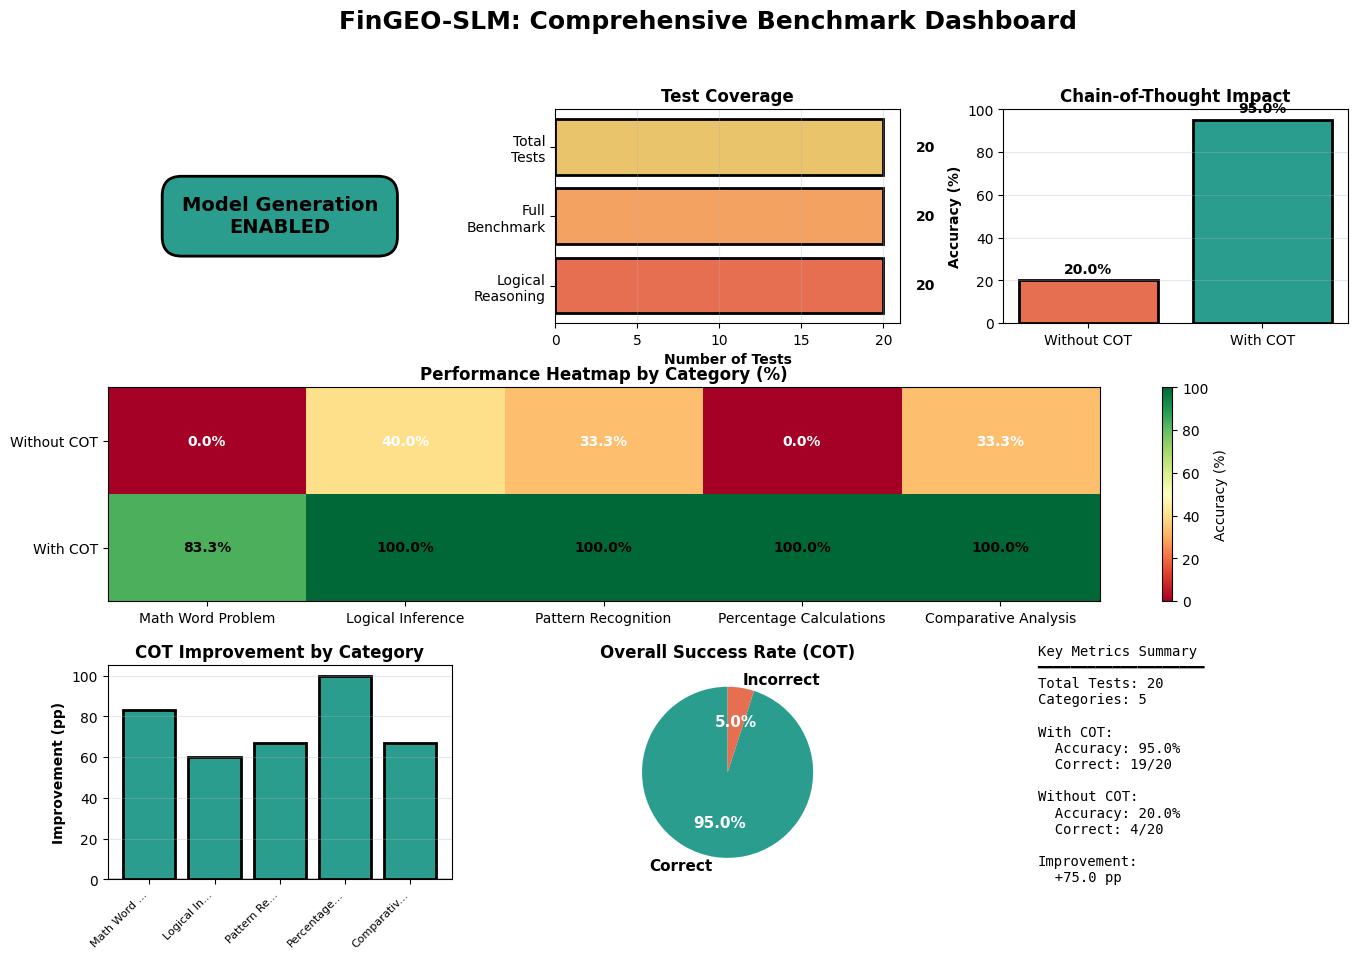


✓ Generated comprehensive benchmark dashboard
  Saved to: fingeo_slm_outputs/enhanced_benchmark_dashboard.png


In [14]:
# Enhanced Benchmark Dashboard
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(16, 10))
gs = GridSpec(3, 3, figure=fig, hspace=0.3, wspace=0.3)
fig.suptitle('FinGEO-SLM: Comprehensive Benchmark Dashboard', fontsize=18, fontweight='bold')

# 1. Model Generation Status (Top Left)
ax1 = fig.add_subplot(gs[0, 0])
# Check if ENABLE_MODEL_GENERATION is defined
try:
    enable_model_gen = ENABLE_MODEL_GENERATION
except NameError:
    enable_model_gen = False

status_color = '#2a9d8f' if enable_model_gen else '#e76f51'
status_text = 'ENABLED' if enable_model_gen else 'DISABLED'
ax1.text(0.5, 0.5, f'Model Generation\n{status_text}', 
        ha='center', va='center', fontsize=14, fontweight='bold',
        bbox=dict(boxstyle='round,pad=1', facecolor=status_color, edgecolor='black', linewidth=2))
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.axis('off')

# 2. Test Coverage (Top Middle)
ax2 = fig.add_subplot(gs[0, 1])
test_categories = ['Logical\nReasoning', 'Full\nBenchmark', 'Total\nTests']
test_counts = [len(LOGICAL_REASONING_TESTS), len(full_results), len(LOGICAL_REASONING_TESTS)]  # Example counts
colors_test = ['#e76f51', '#f4a261', '#e9c46a']
bars = ax2.barh(test_categories, test_counts, color=colors_test, edgecolor='black', linewidth=2)
ax2.set_xlabel('Number of Tests', fontweight='bold')
ax2.set_title('Test Coverage', fontweight='bold')
for bar, count in zip(bars, test_counts):
    width = bar.get_width()
    ax2.text(width + 2, bar.get_y() + bar.get_height()/2, str(count),
            ha='left', va='center', fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# 3. COT Impact (Top Right)
ax3 = fig.add_subplot(gs[0, 2])
cot_comparison = ['Without COT', 'With COT']
cot_scores = [no_cot_results['accuracy'] * 100, cot_results['accuracy'] * 100]
colors_cot = ['#e76f51', '#2a9d8f']
bars = ax3.bar(cot_comparison, cot_scores, color=colors_cot, edgecolor='black', linewidth=2)
ax3.set_ylabel('Accuracy (%)', fontweight='bold')
ax3.set_title('Chain-of-Thought Impact', fontweight='bold')
ax3.set_ylim(0, 100)
for bar, score in zip(bars, cot_scores):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, height + 2,
            f'{score:.1f}%', ha='center', va='bottom', fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# 4. Category Performance Heatmap (Middle Row)
ax4 = fig.add_subplot(gs[1, :])
categories_heat = list(cot_results['category_scores'].keys())
methods_heat = ['Without COT', 'With COT']
heat_data = []
for method_results in [no_cot_results, cot_results]:
    row = []
    for cat in categories_heat:
        scores = method_results['category_scores'][cat]
        acc = scores['correct'] / scores['total'] * 100 if scores['total'] > 0 else 0
        row.append(acc)
    heat_data.append(row)

import numpy as np
heat_array = np.array(heat_data)
im = ax4.imshow(heat_array, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)
ax4.set_xticks(np.arange(len(categories_heat)))
ax4.set_yticks(np.arange(len(methods_heat)))
ax4.set_xticklabels(categories_heat)
ax4.set_yticklabels(methods_heat)
ax4.set_title('Performance Heatmap by Category (%)', fontweight='bold', fontsize=12)

# Add text annotations
for i in range(len(methods_heat)):
    for j in range(len(categories_heat)):
        text = ax4.text(j, i, f'{heat_array[i, j]:.1f}%',
                       ha='center', va='center', fontweight='bold',
                       color='white' if heat_array[i, j] < 50 else 'black')

plt.colorbar(im, ax=ax4, label='Accuracy (%)')

# 5. Improvement Distribution (Bottom Left)
ax5 = fig.add_subplot(gs[2, 0])
improvements_dist = [cot_results['category_scores'][cat]['correct'] / cot_results['category_scores'][cat]['total'] * 100 -
                     no_cot_results['category_scores'][cat]['correct'] / no_cot_results['category_scores'][cat]['total'] * 100
                     for cat in categories_heat]
colors_imp = ['#2a9d8f' if imp >= 0 else '#e76f51' for imp in improvements_dist]
bars = ax5.bar(range(len(categories_heat)), improvements_dist, color=colors_imp, edgecolor='black', linewidth=2)
ax5.set_xticks(range(len(categories_heat)))
ax5.set_xticklabels([cat[:10] + '...' if len(cat) > 10 else cat for cat in categories_heat], 
                    rotation=45, ha='right', fontsize=8)
ax5.set_ylabel('Improvement (pp)', fontweight='bold')
ax5.set_title('COT Improvement by Category', fontweight='bold')
ax5.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax5.grid(axis='y', alpha=0.3)

# 6. Success Rate Pie (Bottom Middle)
ax6 = fig.add_subplot(gs[2, 1])
pie_labels = ['Correct', 'Incorrect']
pie_sizes = [cot_results['correct'], cot_results['incorrect']]
pie_colors = ['#2a9d8f', '#e76f51']
wedges, texts, autotexts = ax6.pie(pie_sizes, labels=pie_labels, colors=pie_colors,
                                    autopct='%1.1f%%', startangle=90,
                                    textprops={'fontweight': 'bold', 'fontsize': 11})
for autotext in autotexts:
    autotext.set_color('white')
ax6.set_title('Overall Success Rate (COT)', fontweight='bold')

# 7. Key Metrics Summary (Bottom Right)
ax7 = fig.add_subplot(gs[2, 2])
metrics_text = f"""Key Metrics Summary
━━━━━━━━━━━━━━━━━━━━
Total Tests: {len(LOGICAL_REASONING_TESTS)}
Categories: {len(categories_heat)}

With COT:
  Accuracy: {cot_results['accuracy']:.1%}
  Correct: {cot_results['correct']}/{cot_results['total']}

Without COT:
  Accuracy: {no_cot_results['accuracy']:.1%}
  Correct: {no_cot_results['correct']}/{no_cot_results['total']}

Improvement:
  +{(cot_results['accuracy'] - no_cot_results['accuracy'])*100:.1f} pp
"""
ax7.text(0.1, 0.5, metrics_text, fontsize=10, fontfamily='monospace',
        va='center', ha='left')
ax7.axis('off')

# Ensure PROJECT_ROOT is defined
try:
    output_dir = PROJECT_ROOT / 'fingeo_slm_outputs'
except NameError:
    from pathlib import Path
    PROJECT_ROOT = Path.cwd()
    output_dir = PROJECT_ROOT / 'fingeo_slm_outputs'

# Create output directory if it doesn't exist
output_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(output_dir / 'enhanced_benchmark_dashboard.png', 
           dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Generated comprehensive benchmark dashboard")
print(f"  Saved to: fingeo_slm_outputs/enhanced_benchmark_dashboard.png")
